In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load both CSV files from 2nd probe in RSP : run in CEPH 
file1 = "/Volumes/margrie/mvelez/mateoData_probe/CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2/csv/clusters_janelia.csv"
file2 = "/Volumes/margrie/alexia/SWC/data/raw_data/janelia_pipeline/V0CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2/csv/clusters_janelia.csv"

#Very first probe ran by the pipeline: in RSP
file3 = "/Volumes/margrie/mvelez/mateoData_probe/CAA-1123432a/output/catgt_CAA-1123432a_rec1_g0/CAA-1123432a_rec1_g0_imec0/imec0_ks2/csv/clusters_janelia.csv"
file4 = "/Volumes/margrie/alexia/SWC/data/raw_data/janelia_pipeline/CAA-1123432a/output/catgt_CAA-1123432a_rec1_g0/CAA-1123432a_rec1_g0_imec0/imec0_ks2/csv/clusters_janelia.csv"

#TO run locally 
#file1= r"Z:\alexia\SWC\KS2_clusters_janelia.csv"
#file2= r"Z:\alexia\SWC\data\raw_data\janelia_pipeline\V0CAA-1123475a\output\catgt_CAA-1123475a_rec1_g0\CAA-1123475a_rec1_g0_imec0\imec0_ks2\csv\clusters_janelia.csv"
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

df3 = pd.read_csv(file3)
df4 = pd.read_csv(file4) 

In [20]:
df1.head(), df2.head(), df3.head(), df4.head()

(   Var1  cluster_id  firing_rate  presence_ratio  isi_viol  num_viol  \
 0     5           6     1.932316            0.89  0.000000         0   
 1     7           9     3.798648            0.99  0.037489         4   
 2    20          22     3.210340            0.97  0.039446         3   
 3    21          23     7.572290            0.99  0.073507        30   
 4    22          24     0.080224            0.22  0.000000         0   
 
    amplitude_cutoff  isolation_distance  contam_rate   l_ratio   d_prime  \
 0          0.001531           64.174363     0.000000  0.000880  5.036817   
 1          0.071040           92.553083     0.298494  0.002606  3.571452   
 2          0.026796           92.115210     0.225048  0.009352  5.175985   
 3          0.016712           71.818477     4.004586  0.049909  2.723694   
 4          0.014107           92.470841     0.000000  0.000021  4.787189   
 
    nn_hit_rate  nn_miss_rate  silhouette_score  max_drift  cumulative_drift  \
 0     0.998667 

In [24]:
print(f"KS2 Probe 1 clusters: {len(df1)}")
print(f"KS2.5 clusters: {len(df2)}\n")
print(f"KS2 Probe 2 clusters: {len(df3)}")
print(f"KS2.5 Probe 2 clusters: {len(df4)}")

KS2 Probe 1 clusters: 85
KS2.5 clusters: 111

KS2 Probe 2 clusters: 84
KS2.5 Probe 2 clusters: 85


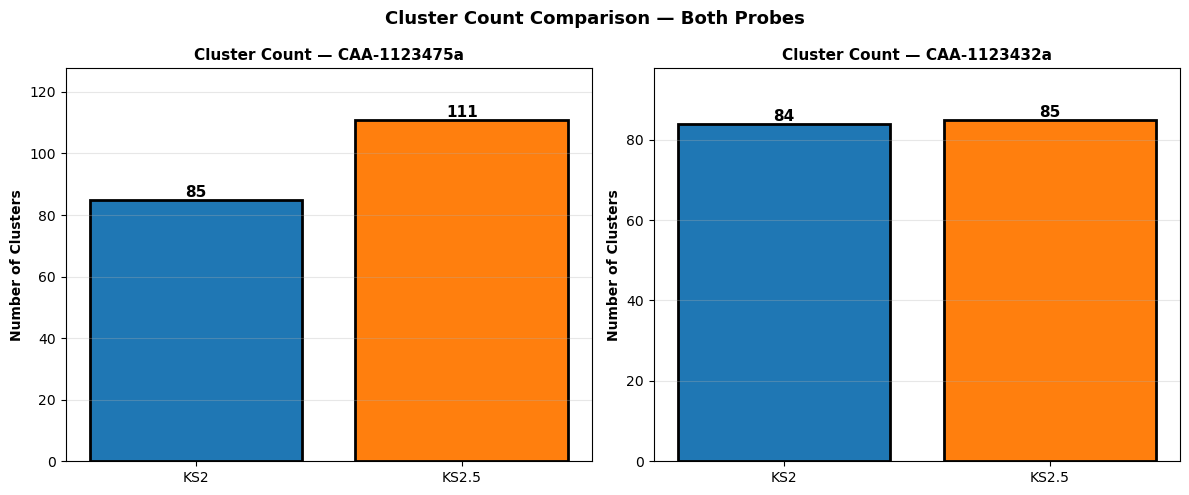

In [25]:
# 1. Plot cluster counts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df_ks2, df_ks25, probe_name in [
    (axes[0], df1, df2, 'CAA-1123475a'),
    (axes[1], df3, df4, 'CAA-1123432a'),
]:
    cluster_counts = [len(df_ks2), len(df_ks25)]
    bars = ax.bar(['KS2', 'KS2.5'], cluster_counts,
                  color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Clusters', fontsize=10, fontweight='bold')
    ax.set_title(f'Cluster Count — {probe_name}', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(cluster_counts) * 1.15)
    for bar, count in zip(bars, cluster_counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{int(count)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Count Comparison — Both Probes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [38]:
exclude_cols = {'Var1', 'cluster_id', 'epoch_name_quality_metrics', 'epoch_name_waveform_metrics'}

# Probe A — colonnes de df1 qui existent aussi dans df2
numeric_cols_A = [col for col in df1.columns 
                  if col not in exclude_cols 
                  and df1[col].dtype in ['float64', 'int64']
                  and col in df2.columns]

# Probe B — colonnes de df3 qui existent aussi dans df4
numeric_cols_B = [col for col in df3.columns 
                  if col not in exclude_cols 
                  and df3[col].dtype in ['float64', 'int64']
                  and col in df4.columns]

mean_comparison_A = pd.DataFrame({
    'KS2':   df1[numeric_cols_A].mean(),
    'KS2.5': df2[numeric_cols_A].mean()
})

mean_comparison_B = pd.DataFrame({
    'KS2':   df3[numeric_cols_B].mean(),
    'KS2.5': df4[numeric_cols_B].mean()
})

print(f"Probe A: {len(numeric_cols_A)} common columns ")
print(f"Probe B: {len(numeric_cols_B)} common columns ")

Probe A: 25 common columns 
Probe B: 14 common columns 


/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/

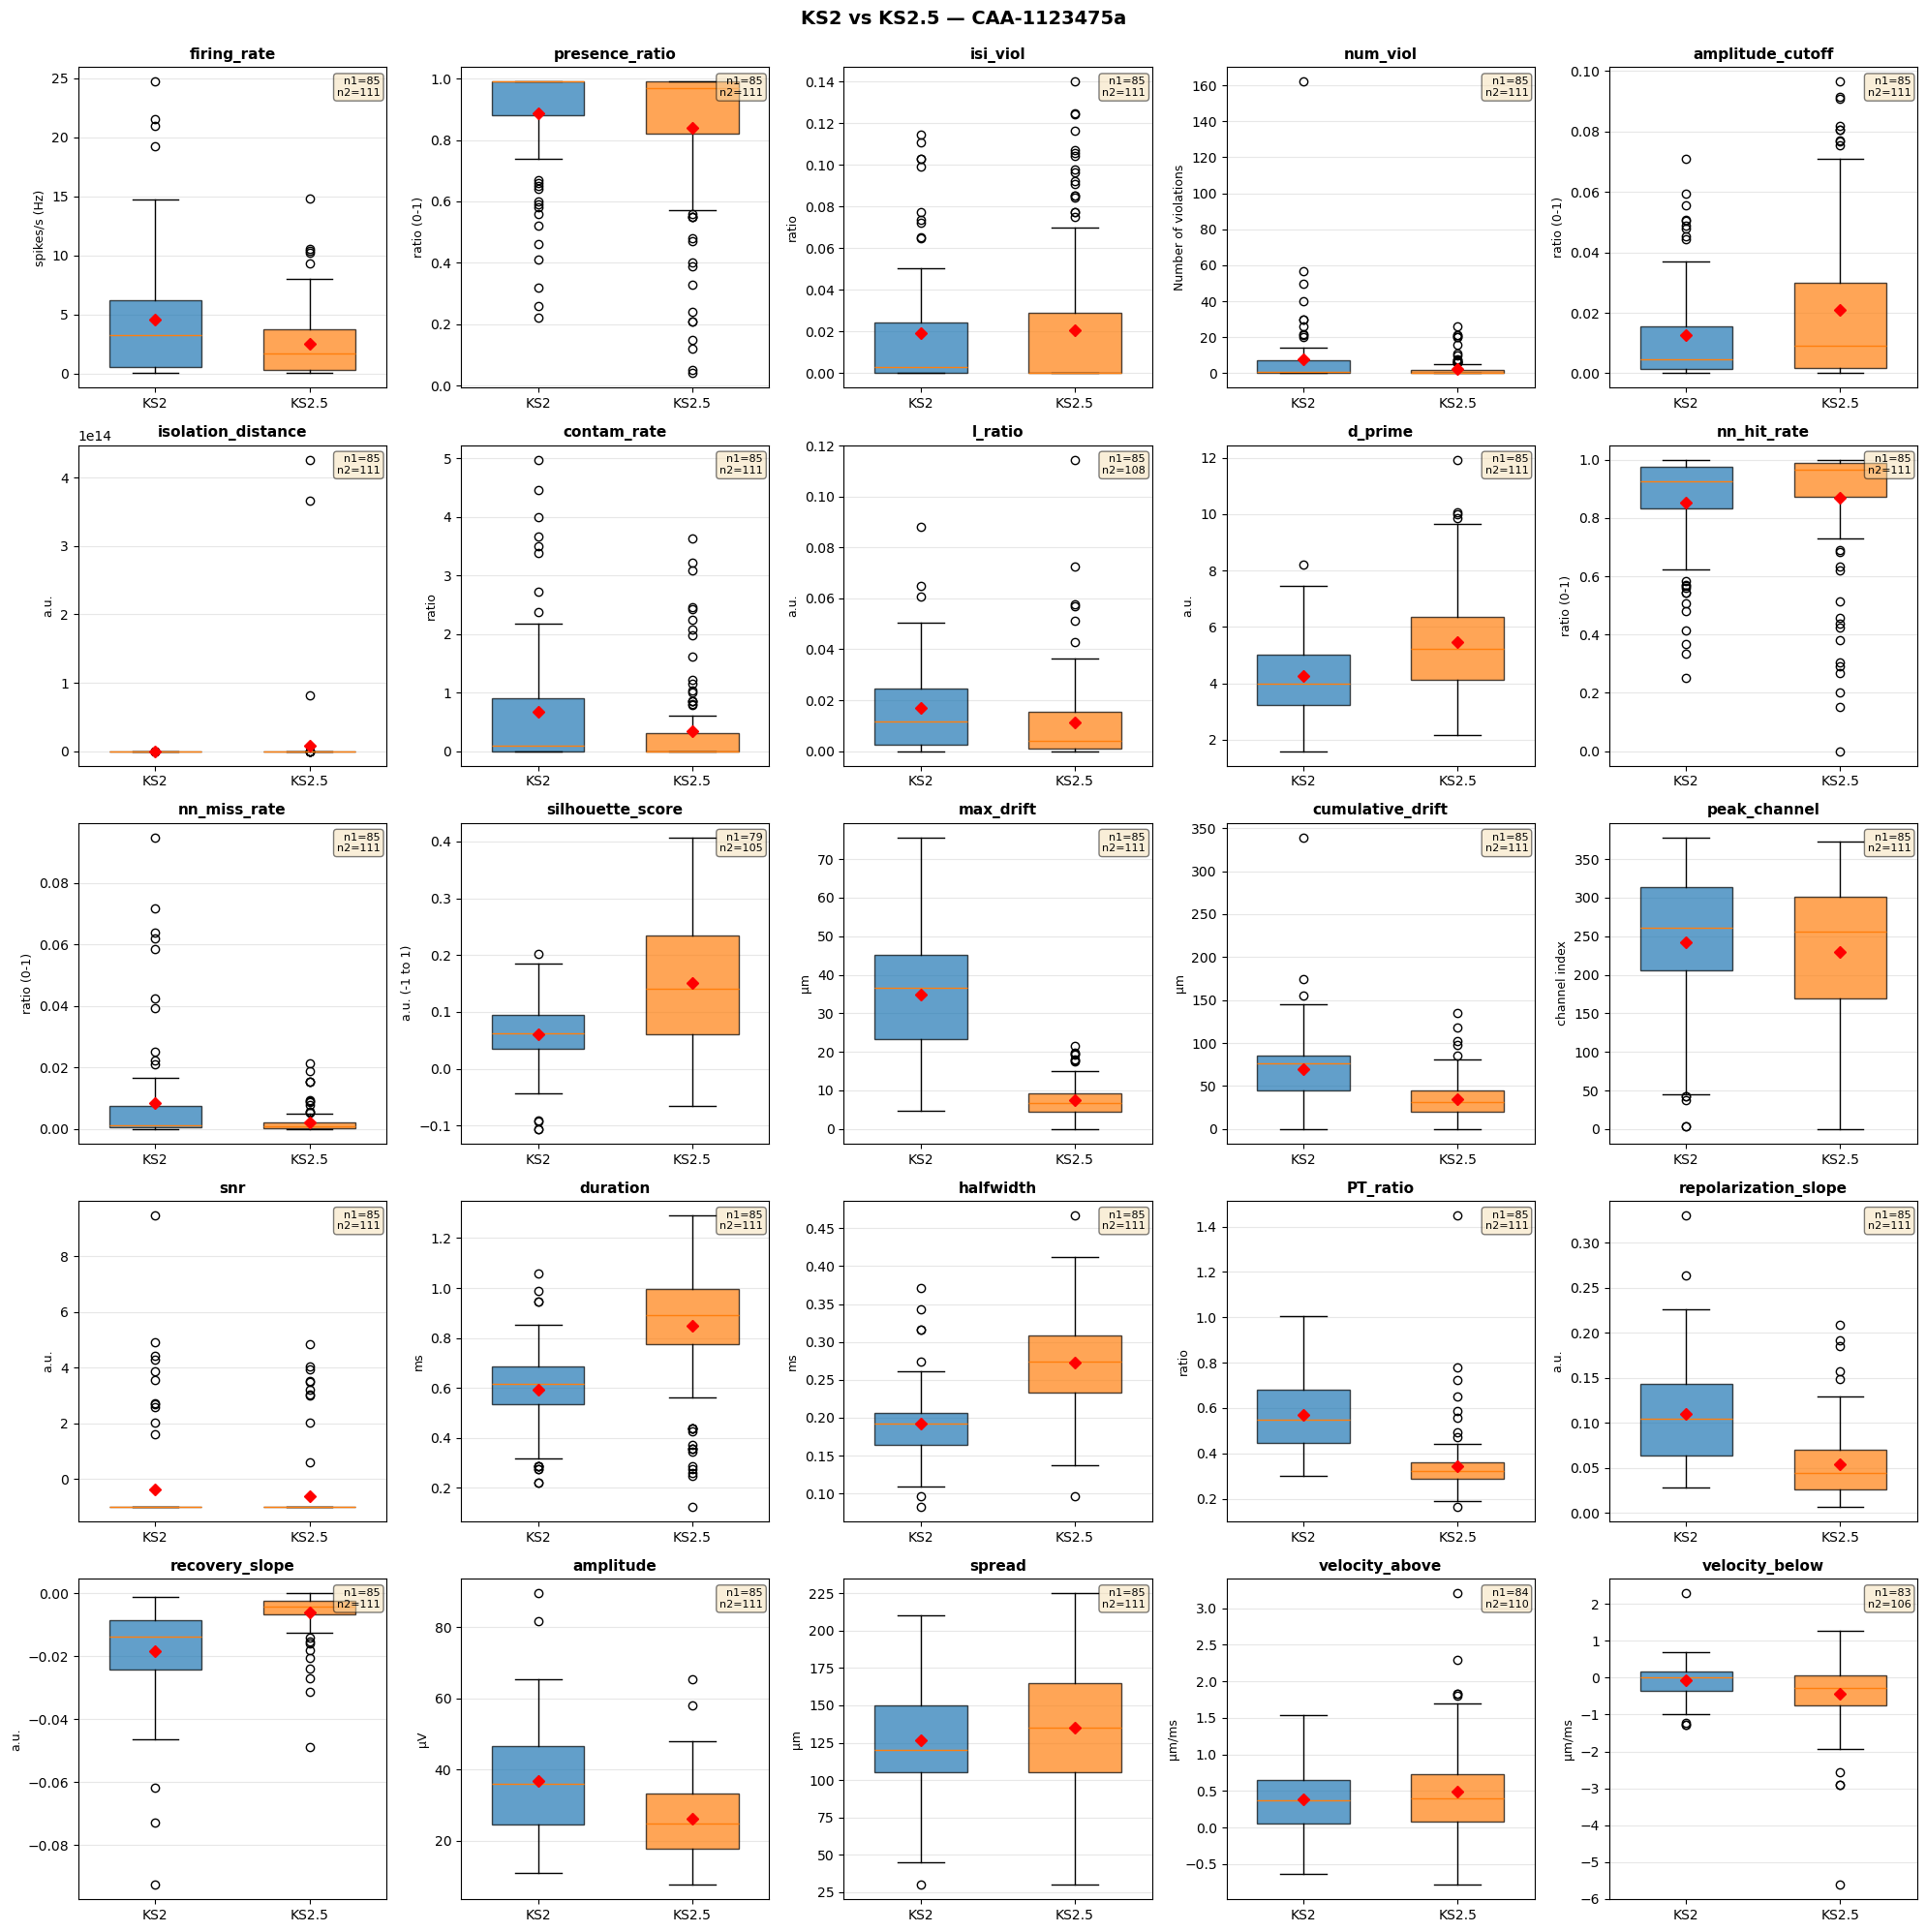

✓ Boxplots done for CAA-1123475a


/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/ipykernel_53150/2749581284.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
/var/folders/3x/rxtl1j4d3sld3llwk8_kc1f40000gn/T/

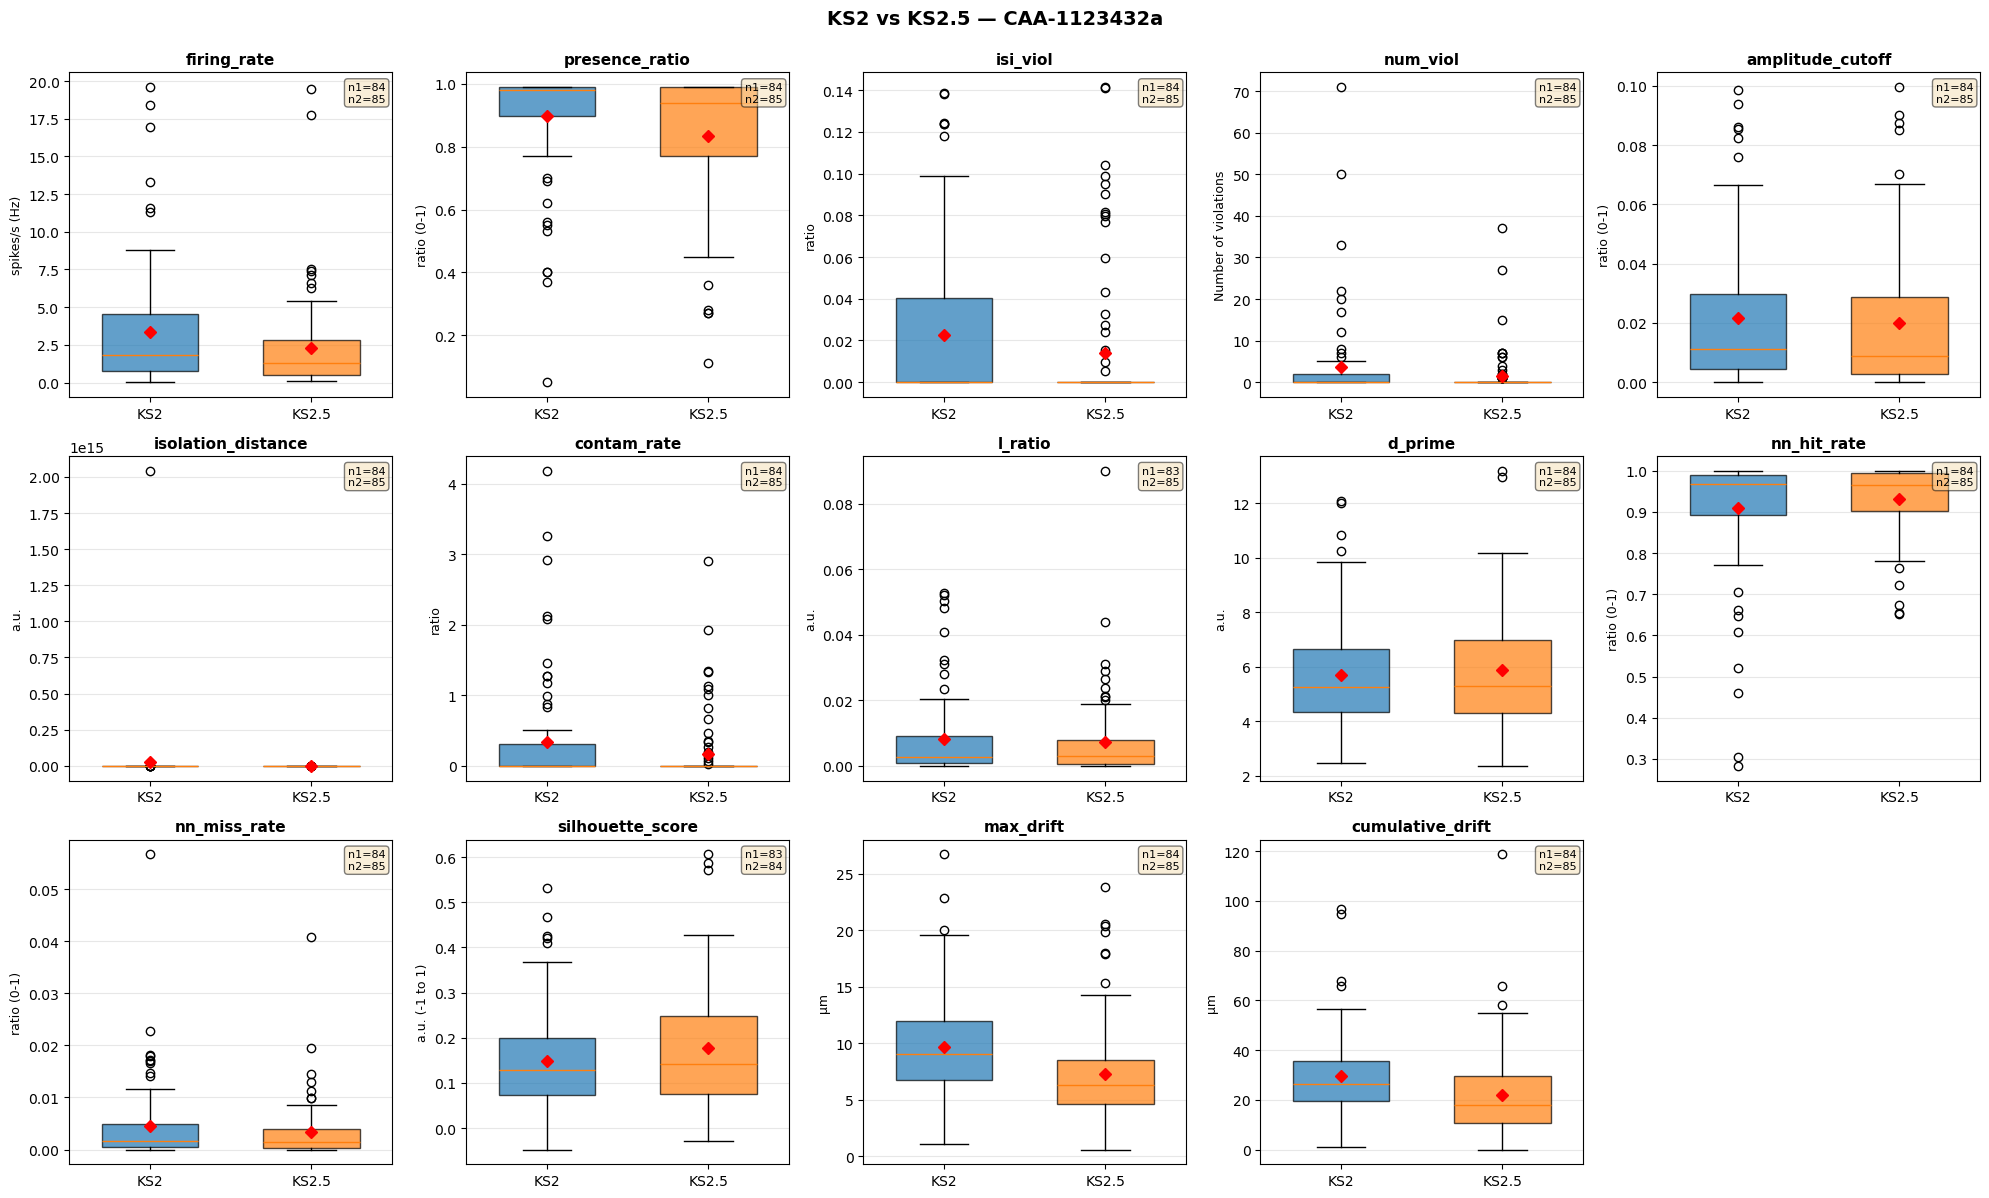

✓ Boxplots done for CAA-1123432a


In [39]:
# units reste identique — pas besoin de le modifier
units = {
    'firing_rate':        'spikes/s (Hz)',
    'presence_ratio':     'ratio (0-1)',
    'isi_viol':           'ratio',
    'num_viol':           'Number of violations',
    'amplitude_cutoff':   'ratio (0-1)',
    'isolation_distance': 'a.u.',
    'contam_rate':        'ratio',
    'l_ratio':            'a.u.',
    'd_prime':            'a.u.',
    'nn_hit_rate':        'ratio (0-1)',
    'nn_miss_rate':       'ratio (0-1)',
    'silhouette_score':   'a.u. (-1 to 1)',
    'max_drift':          'µm',
    'cumulative_drift':   'µm',
    'peak_channel':       'channel index',
    'snr':                'a.u.',
    'duration':           'ms',
    'halfwidth':          'ms',
    'PT_ratio':           'ratio',
    'spread':             'µm',
    'velocity_above':     'µm/ms',
    'velocity_below':     'µm/ms',
    'amplitude':          'µV',
    'depth':              'µm',
}

colors = ['#1f77b4', '#ff7f0e']

# Une figure par probe
for probe_name, df_ks2, df_ks25, numeric_cols in [
    ('CAA-1123475a', df1, df2, numeric_cols_A),
    ('CAA-1123432a', df3, df4, numeric_cols_B),
]:
    n_rows = (len(numeric_cols) + 4) // 5
    fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        bp = ax.boxplot([df_ks2[col].dropna(), df_ks25[col].dropna()],
                        labels=['KS2', 'KS2.5'], patch_artist=True,
                        widths=0.6, showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='red',
                                       markeredgecolor='red', markersize=6))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_ylabel(units.get(col, 'a.u.'), fontsize=9)
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.text(0.98, 0.97,
                f'n1={len(df_ks2[col].dropna())}\nn2={len(df_ks25[col].dropna())}',
                transform=ax.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(f'KS2 vs KS2.5 — {probe_name}', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    print(f"✓ Boxplots done for {probe_name}")


STATISTICAL COMPARISON: KS2 vs KS2.5 — CAA-1123475a
Parameter                 Normality (KS2) Normality (KS2.5) Test Used       p-value      Significant*
------------------------------------------------------------------------------------------
firing_rate               Not Normal      Not Normal      Mann-Whitney U  0.0077       Yes **      
presence_ratio            Not Normal      Not Normal      Mann-Whitney U  0.0773       No          
isi_viol                  Not Normal      Not Normal      Mann-Whitney U  0.1560       No          
num_viol                  Not Normal      Not Normal      Mann-Whitney U  0.0056       Yes **      
amplitude_cutoff          Not Normal      Not Normal      Mann-Whitney U  0.0827       No          
isolation_distance        Not Normal      Not Normal      Mann-Whitney U  0.0728       No          
contam_rate               Not Normal      Not Normal      Mann-Whitney U  0.0123       Yes *       
l_ratio                   Not Normal      Not Normal  

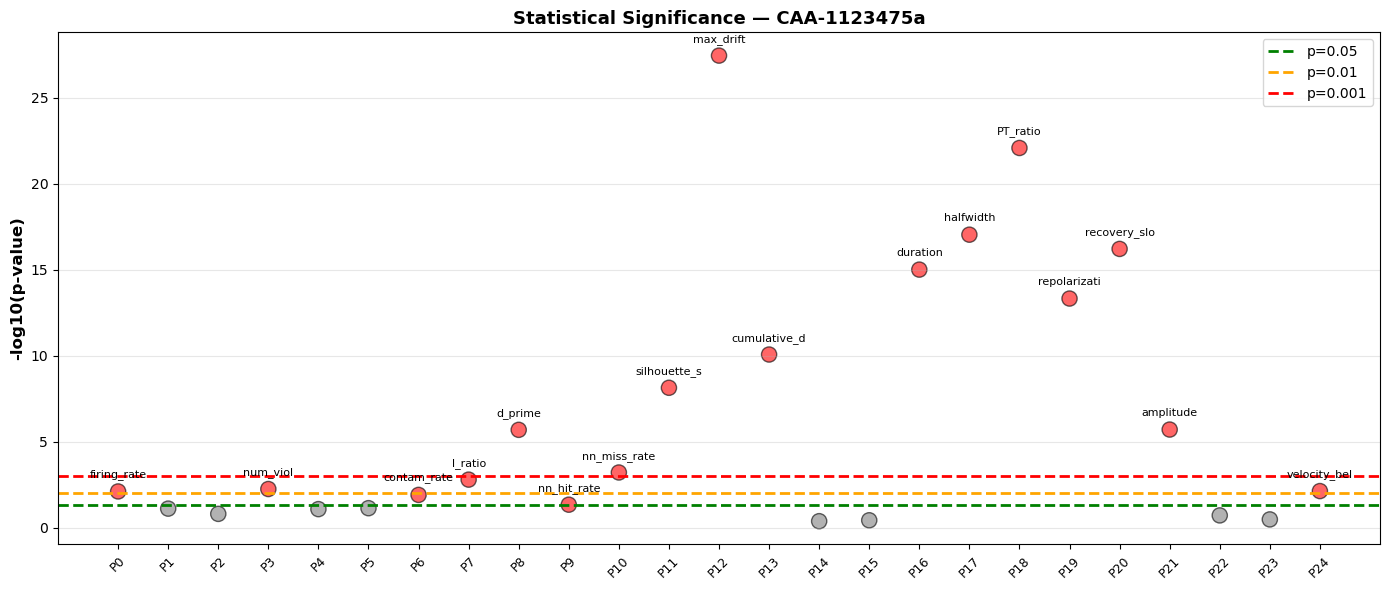

✓ Statistical analysis complete for CAA-1123475a!

STATISTICAL COMPARISON: KS2 vs KS2.5 — CAA-1123432a
Parameter                 Normality (KS2) Normality (KS2.5) Test Used       p-value      Significant*
------------------------------------------------------------------------------------------
firing_rate               Not Normal      Not Normal      Mann-Whitney U  0.0616       No          
presence_ratio            Not Normal      Not Normal      Mann-Whitney U  0.0430       Yes *       
isi_viol                  Not Normal      Not Normal      Mann-Whitney U  0.0275       Yes *       
num_viol                  Not Normal      Not Normal      Mann-Whitney U  0.0162       Yes *       
amplitude_cutoff          Not Normal      Not Normal      Mann-Whitney U  0.3594       No          
isolation_distance        Not Normal      Not Normal      Mann-Whitney U  0.7425       No          
contam_rate               Not Normal      Not Normal      Mann-Whitney U  0.0164       Yes *       
l_ra

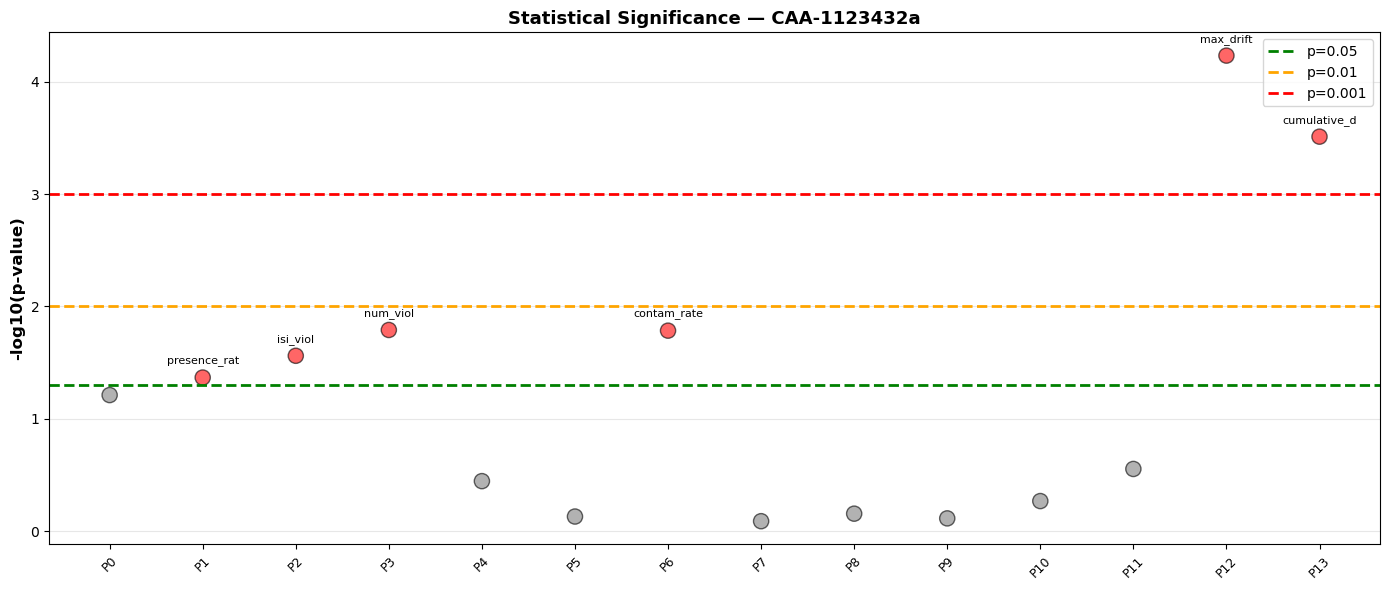

✓ Statistical analysis complete for CAA-1123432a!


In [40]:
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
np.set_printoptions(threshold=np.inf)

# Une boucle sur les deux probes
all_results = {}

for probe_name, df_ks2, df_ks25, numeric_cols in [
    ('CAA-1123475a', df1, df2, numeric_cols_A),
    ('CAA-1123432a', df3, df4, numeric_cols_B),
]:
    results = []
    print(f"\n{'='*90}")
    print(f"STATISTICAL COMPARISON: KS2 vs KS2.5 — {probe_name}")
    print(f"{'='*90}")
    print(f"{'Parameter':<25} {'Normality (KS2)':<15} {'Normality (KS2.5)':<15} {'Test Used':<15} {'p-value':<12} {'Significant*':<12}")
    print("-"*90)

    for col in numeric_cols:
        data1 = df_ks2[col].dropna()
        data2 = df_ks25[col].dropna()
        _, p_norm1 = stats.shapiro(data1)
        _, p_norm2 = stats.shapiro(data2)
        norm1 = "Normal" if p_norm1 > 0.05 else "Not Normal"
        norm2 = "Normal" if p_norm2 > 0.05 else "Not Normal"
        if p_norm1 > 0.05 and p_norm2 > 0.05:
            _, p_value = stats.ttest_ind(data1, data2)
            test_used = "t-test"
        else:
            _, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            test_used = "Mann-Whitney U"
        significant = ("Yes ***" if p_value < 0.001 else "Yes **" if p_value < 0.01
                       else "Yes *" if p_value < 0.05 else "No")
        results.append({'Parameter': col, 'Normality_KS2': norm1, 'Normality_KS2.5': norm2,
                        'Test': test_used, 'p_value': p_value, 'Significant': significant,
                        'Mean_KS2': data1.mean(), 'Mean_KS2.5': data2.mean()})
        print(f"{col:<25} {norm1:<15} {norm2:<15} {test_used:<15} {p_value:<12.4f} {significant:<12}", flush=True)

    print("-"*90)
    results_df = pd.DataFrame(results)
    all_results[probe_name] = results_df

    print(f"\nTotal parameters tested: {len(numeric_cols)}")
    print(f"Significant (p<0.05): {len(results_df[results_df['p_value'] < 0.05])}")
    print(f"Top 5 Most Significant:")
    for _, row in results_df.nsmallest(5, 'p_value').iterrows():
        print(f"  {row['Parameter']:<25} KS2: {row['Mean_KS2']:>8.4f}  |  KS2.5: {row['Mean_KS2.5']:>8.4f}  |  p={row['p_value']:.4f}")

    # Volcano plot
    fig, ax = plt.subplots(figsize=(14, 6))
    colors_sig = ['red' if p < 0.05 else 'gray' for p in results_df['p_value']]
    ax.scatter(range(len(results_df)), -np.log10(results_df['p_value']),
               c=colors_sig, alpha=0.6, s=120, edgecolors='black', linewidth=1)
    for thr, col, lbl in [(0.05,'green','p=0.05'), (0.01,'orange','p=0.01'), (0.001,'red','p=0.001')]:
        ax.axhline(-np.log10(thr), color=col, linestyle='--', linewidth=2, label=lbl)
    for i, row in results_df.iterrows():
        if row['p_value'] < 0.05:
            ax.annotate(row['Parameter'][:12], (i, -np.log10(row['p_value'])),
                        textcoords='offset points', xytext=(0,10), ha='center', fontsize=8)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels([f'P{i}' for i in range(len(results_df))], fontsize=9, rotation=45)
    ax.set_ylabel('-log10(p-value)', fontsize=12, fontweight='bold')
    ax.set_title(f'Statistical Significance — {probe_name}', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"✓ Statistical analysis complete for {probe_name}!")

In [ ]:
import numpy as np
from pathlib import Path
import pandas as pd

#Too run fron the local computer 
#ks_dir = Path(r'Z:\alexia\SWC\data\raw_data\janelia_pipeline\V0CAA-1123475a\output\catgt_CAA-1123475a_rec1_g0\CAA-1123475a_rec1_g0_imec0\imec0_ks2')


#To run on MAC from CEPH
ks_dir = Path('/Volumes/margrie/alexia/SWC/data/raw_data/janelia_pipeline/V0CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2')

spike_clusters = np.load(ks_dir / 'spike_clusters.npy')
spike_templates = np.load(ks_dir / 'spike_templates.npy')
channel_positions = np.load(ks_dir / 'channel_positions.npy')

# Load templates
templates = np.load(ks_dir / 'templates.npy')  # (nTemplates, nTimePoints, nChannels) - DENSE, contains all channels

# KEY: Get unique CLUSTER IDs (not template indices!)
unique_clusters = np.unique(spike_clusters)
print(f"Processing {len(unique_clusters)} clusters of KS2.5")
print(f"Cluster ID range: {unique_clusters.min()} to {unique_clusters.max()}")
print(f"Probe has {channel_positions.shape[0]} channels\n")

cluster_depths = []

# For each CLUSTER, compute depth from channel_positions y-coordinate
for cluster_id in unique_clusters:
    spike_ids = np.where(spike_clusters == cluster_id)[0]
    
    if len(spike_ids) == 0:
        continue
    
    # Get the template IDs for spikes in this cluster
    spike_templates_in_cluster = spike_templates[spike_ids].squeeze()
    
    # Find the MOST COMMON template for this cluster
    template_ids, counts = np.unique(spike_templates_in_cluster, return_counts=True)
    best_template_id = template_ids[np.argmax(counts)]
    
    # Get the template waveform (all channels)
    template_waveform = templates[best_template_id, :, :]  # (nTimePoints, nChannels)
    
    # Compute mean absolute amplitude on each channel
    channel_amplitudes = np.mean(np.abs(template_waveform), axis=0)  # (nChannels,)
    
    # Find channel with maximum amplitude (best channel)
    best_channel = np.argmax(channel_amplitudes)
    
    # Get depth from channel position (y-coordinate)
    depth = channel_positions[best_channel, 1]
    n_spikes = len(spike_ids)
    
    cluster_depths.append({
        'cluster_id': cluster_id,
        'depth_um': depth,
        'n_spikes': n_spikes,
        'best_template_id': best_template_id,
        'best_channel': best_channel,
        'best_channel_amplitude': channel_amplitudes[best_channel]
    })

# Create DataFrame from results
depths_df = pd.DataFrame(cluster_depths)
depths_df = depths_df.sort_values('cluster_id').reset_index(drop=True)

print(f"✓ Extracted depths for {len(depths_df)} clusters\n")
print("Sample of extracted depths:")
print(depths_df.head(15))
print(f"\n...and {len(depths_df)-15} more clusters\n")
print(f"Depth statistics:")
print(f"  Mean depth:    {depths_df['depth_um'].mean():.1f} µm")
print(f"  Std depth:     {depths_df['depth_um'].std():.1f} µm")
print(f"  Min depth:     {depths_df['depth_um'].min():.1f} µm")
print(f"  Max depth:     {depths_df['depth_um'].max():.1f} µm")
print(f"  Median depth:  {depths_df['depth_um'].median():.1f} µm")
print(f"\nBest channel distribution:")
print(f"  Channels used: {depths_df['best_channel'].nunique()} unique channels")
print(f"  Channel range: {depths_df['best_channel'].min()} to {depths_df['best_channel'].max()}")
print(f"\nSpike count statistics:")
print(f"  Mean n_spikes: {depths_df['n_spikes'].mean():.0f}")
print(f"  Min n_spikes:  {depths_df['n_spikes'].min()}")
print(f"  Max n_spikes:  {depths_df['n_spikes'].max()}")

Processing 603 clusters...
Cluster ID range: 0 to 638
Probe has 384 channels

✓ Extracted depths for 603 clusters

Sample of extracted depths:
    cluster_id  depth_um  n_spikes  best_template_id  best_channel  \
0            0       0.0      5647                 0             1   
1            1       0.0     13652                 1             1   
2            3       0.0        39                 3             1   
3            4       0.0        41                 4             1   
4            5      15.0      3196                 5             2   
5            6      15.0        34                 6             3   
6            7      30.0      6947                 7             4   
7            8      75.0       340                 8            10   
8            9      45.0      6362                 9             7   
9           10      75.0        80                10            11   
10          11      15.0        14                11             2   
11          12   

Total clusters with depth info: 603
Clusters in df2: 111
Clusters in df2 with depth info: 111

Amplitude statistics for df2 clusters:
  Mean:   26.1705
  Std:    11.4124
  Min:    7.6575
  Max:    65.3342


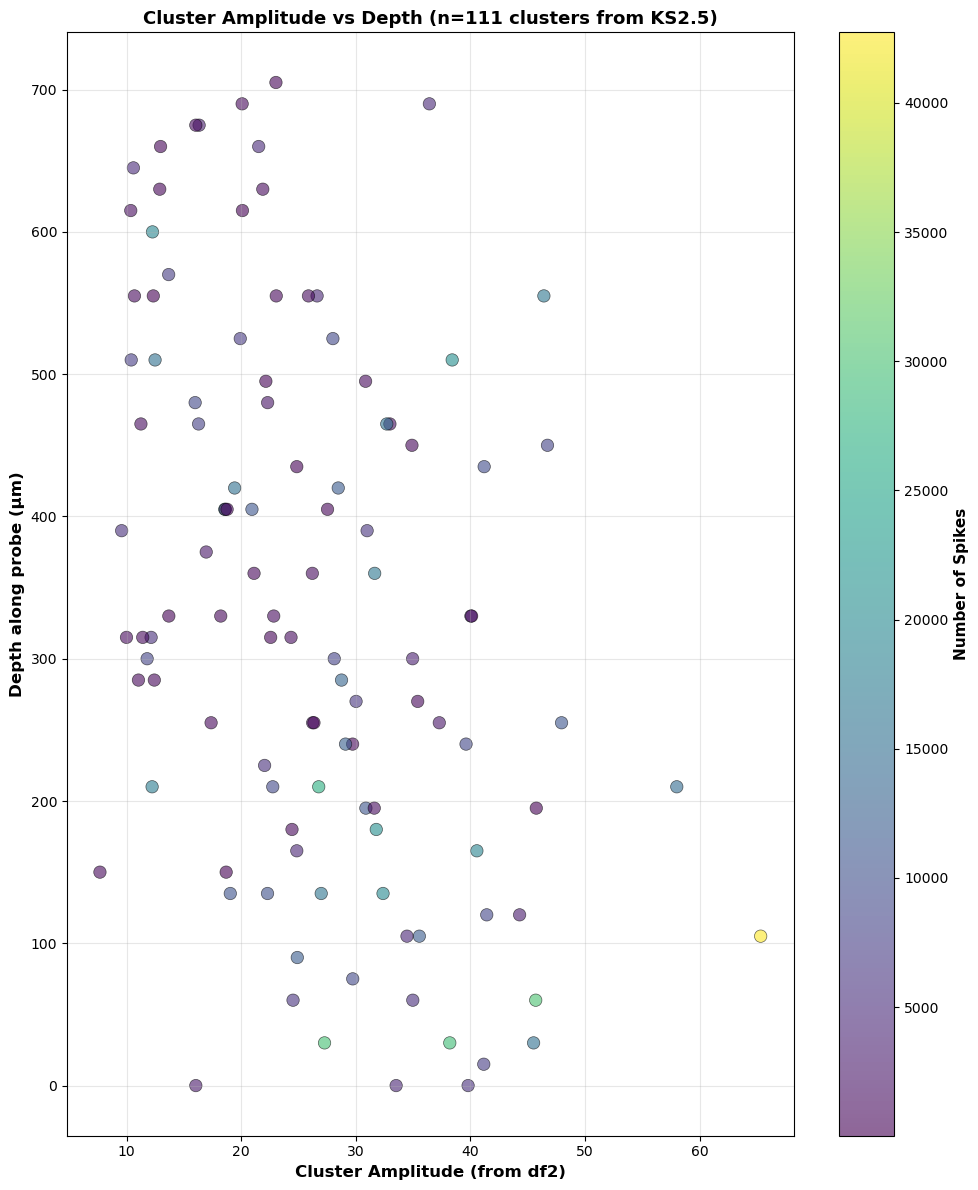


✓ Scatter plot created!


In [10]:
# Filter depths_df to only include clusters present in df2
#This is the results of the KS2.5 pipeline
clusters_in_df2 = set(df2['cluster_id'].values)
depths_df2_filtered = depths_df[depths_df['cluster_id'].isin(clusters_in_df2)].copy()

# Merge with df2 to get the amplitude from df2
depths_df2_filtered = depths_df2_filtered.merge(df2[['cluster_id', 'amplitude']], on='cluster_id', how='left')

print(f"Total clusters with depth info: {len(depths_df)}")
print(f"Clusters in df2: {len(df2)}")
print(f"Clusters in df2 with depth info: {len(depths_df2_filtered)}")
print(f"\nAmplitude statistics for df2 clusters:")
print(f"  Mean:   {depths_df2_filtered['amplitude'].mean():.4f}")
print(f"  Std:    {depths_df2_filtered['amplitude'].std():.4f}")
print(f"  Min:    {depths_df2_filtered['amplitude'].min():.4f}")
print(f"  Max:    {depths_df2_filtered['amplitude'].max():.4f}")

# Create scatter plot: amplitude vs depth (with depth inverted - 0 at top)
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(depths_df2_filtered['amplitude'], 
                     depths_df2_filtered['depth_um'],
                     s=80, alpha=0.6, c=depths_df2_filtered['n_spikes'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)

# Invert y-axis so 0 is at top and depth increases downwards (typical neural probe visualization)
#.invert_yaxis()

ax.set_xlabel('Cluster Amplitude (from df2)', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth along probe (µm)', fontsize=12, fontweight='bold')
ax.set_title(f'Cluster Amplitude vs Depth (n={len(depths_df2_filtered)} clusters from KS2.5)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar for spike count
cbar = plt.colorbar(scatter, ax=ax, label='Number of Spikes')
cbar.ax.set_ylabel('Number of Spikes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Scatter plot created!")

Metrics file loaded with 603 clusters

Metrics columns:
['Unnamed: 0', 'cluster_id', 'firing_rate', 'presence_ratio', 'isi_viol', 'num_viol', 'amplitude_cutoff', 'isolation_distance', 'contam_rate', 'l_ratio', 'd_prime', 'nn_hit_rate', 'nn_miss_rate', 'silhouette_score', 'max_drift', 'cumulative_drift', 'epoch_name_quality_metrics', 'epoch_name_waveform_metrics', 'peak_channel', 'snr', 'duration', 'halfwidth', 'PT_ratio', 'repolarization_slope', 'recovery_slope', 'amplitude', 'spread', 'velocity_above', 'velocity_below']

Metrics head:
   Unnamed: 0  cluster_id  firing_rate  presence_ratio  isi_viol  num_viol  \
0           0           0     1.961141            0.91  0.000000       0.0   
1           1           1     4.741190            0.99  0.061716      10.0   
2           2           3     0.013544            0.26  0.000000       0.0   
3           3           4     0.014239            0.31  0.000000       0.0   
4           4           5     1.109936            0.92  1.000000    

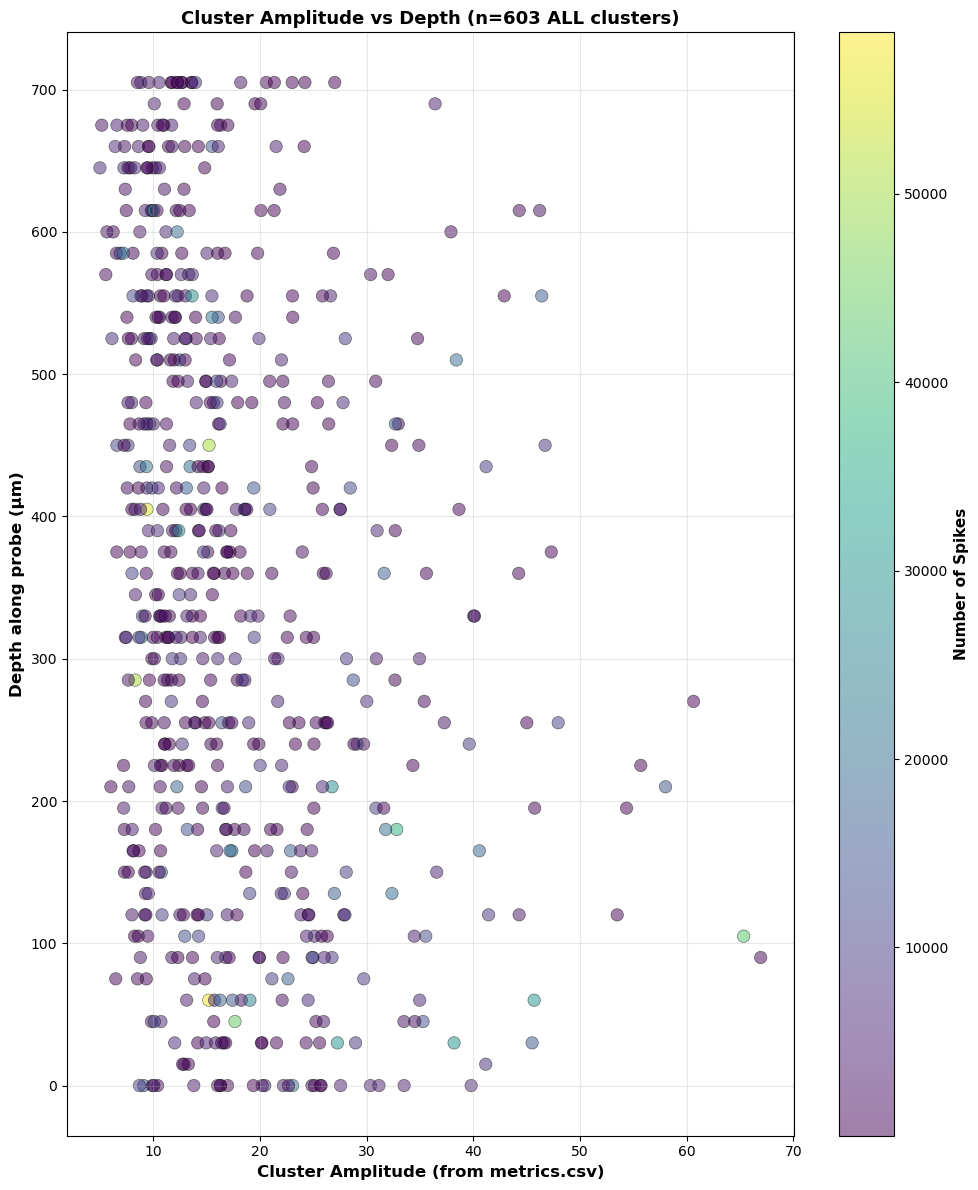


✓ Scatter plot created for all 603 clusters!


In [13]:
# Load metrics.csv for all clusters
#This is the results of the \KS2.5 pipeline, all clusters this time 
metrics_file = r'/Volumes/margrie/alexia/SWC/data/raw_data/janelia_pipeline/V0CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2/csv/metrics.csv'
metrics_df = pd.read_csv(metrics_file)

print(f"Metrics file loaded with {len(metrics_df)} clusters")
print(f"\nMetrics columns:")
print(metrics_df.columns.tolist())
print(f"\nMetrics head:")
print(metrics_df.head())

# Merge depths_df with metrics_df
depths_df_all = depths_df.merge(metrics_df, left_on='cluster_id', right_on='cluster_id', how='left')

print(f"\n✓ Merged {len(depths_df_all)} clusters with amplitude data from metrics.csv")
print(f"\nAmplitude statistics for ALL clusters:")
print(f"  Mean:   {depths_df_all['amplitude'].mean():.4f}")
print(f"  Std:    {depths_df_all['amplitude'].std():.4f}")
print(f"  Min:    {depths_df_all['amplitude'].min():.4f}")
print(f"  Max:    {depths_df_all['amplitude'].max():.4f}")
print(f"  Median: {depths_df_all['amplitude'].median():.4f}")

# Create scatter plot for ALL clusters
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(depths_df_all['amplitude'], 
                     depths_df_all['depth_um'],
                     s=80, alpha=0.5, c=depths_df_all['n_spikes'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)

# Invert y-axis so 0 is at top and depth increases downwards
#.invert_yaxis()

ax.set_xlabel('Cluster Amplitude (from metrics.csv)', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth along probe (µm)', fontsize=12, fontweight='bold')
ax.set_title(f'Cluster Amplitude vs Depth (n={len(depths_df_all)} ALL clusters)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar for spike count
cbar = plt.colorbar(scatter, ax=ax, label='Number of Spikes')
cbar.ax.set_ylabel('Number of Spikes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Scatter plot created for all {len(depths_df_all)} clusters!")

In [15]:
#Now we find the depth for good clusters of KS2 pipeline 

# To run locally (Windows):
# ks_dir = Path(r'Z:\mvelez\mateoData_probe\CAA-1123475a\output\catgt_CAA-1123475a_rec1_g0\CAA-1123475a_rec1_g0_imec0\imec0_ks2')

ks_dir = Path(r'/Volumes/margrie/mvelez/mateoData_probe/CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2')

spike_clusters = np.load(ks_dir / 'spike_clusters.npy')
spike_templates = np.load(ks_dir / 'spike_templates.npy')
channel_positions = np.load(ks_dir / 'channel_positions.npy')

# Load templates
templates = np.load(ks_dir / 'templates.npy')  # (nTemplates, nTimePoints, nChannels) - DENSE, contains all channels

# KEY: Get unique CLUSTER IDs (not template indices!)
unique_clusters = np.unique(spike_clusters)
print(f"Processing {len(unique_clusters)} clusters...")
print(f"Cluster ID range: {unique_clusters.min()} to {unique_clusters.max()}")
print(f"Probe has {channel_positions.shape[0]} channels\n")

cluster_depths = []

# For each CLUSTER, compute depth from channel_positions y-coordinate
for cluster_id in unique_clusters:
    spike_ids = np.where(spike_clusters == cluster_id)[0]
    
    if len(spike_ids) == 0:
        continue
    
    # Get the template IDs for spikes in this cluster
    spike_templates_in_cluster = spike_templates[spike_ids].squeeze()
    
    # Find the MOST COMMON template for this cluster
    template_ids, counts = np.unique(spike_templates_in_cluster, return_counts=True)
    best_template_id = template_ids[np.argmax(counts)]
    
    # Get the template waveform (all channels)
    template_waveform = templates[best_template_id, :, :]  # (nTimePoints, nChannels)
    
    # Compute mean absolute amplitude on each channel
    channel_amplitudes = np.mean(np.abs(template_waveform), axis=0)  # (nChannels,)
    
    # Find channel with maximum amplitude (best channel)
    best_channel = np.argmax(channel_amplitudes)
    
    # Get depth from channel position (y-coordinate)
    depth = channel_positions[best_channel, 1]
    n_spikes = len(spike_ids)
    
    cluster_depths.append({
        'cluster_id': cluster_id,
        'depth_um': depth,
        'n_spikes': n_spikes,
        'best_template_id': best_template_id,
        'best_channel': best_channel,
        'best_channel_amplitude': channel_amplitudes[best_channel]
    })

# Create DataFrame from results
depths_df1= pd.DataFrame(cluster_depths)
depths_df1= depths_df1.sort_values('cluster_id').reset_index(drop=True)

print(f"✓ Extracted depths for {len(depths_df1)} clusters\n")
print("Sample of extracted depths:")
print(depths_df1.head(15))
print(f"\n...and {len(depths_df1)-15} more clusters\n")
print(f"Depth statistics:")
print(f"  Mean depth:    {depths_df1['depth_um'].mean():.1f} µm")
print(f"  Std depth:     {depths_df1['depth_um'].std():.1f} µm")
print(f"  Min depth:     {depths_df1['depth_um'].min():.1f} µm")
print(f"  Max depth:     {depths_df1['depth_um'].max():.1f} µm")
print(f"  Median depth:  {depths_df1['depth_um'].median():.1f} µm")
print(f"\nBest channel distribution:")
print(f"  Channels used: {depths_df1['best_channel'].nunique()} unique channels")
print(f"  Channel range: {depths_df1['best_channel'].min()} to {depths_df1['best_channel'].max()}")
print(f"\nSpike count statistics:")
print(f"  Mean n_spikes: {depths_df1['n_spikes'].mean():.0f}")
print(f"  Min n_spikes:  {depths_df1['n_spikes'].min()}")
print(f"  Max n_spikes:  {depths_df1['n_spikes'].max()}")

Processing 373 clusters...
Cluster ID range: 0 to 385
Probe has 384 channels

✓ Extracted depths for 373 clusters

Sample of extracted depths:
    cluster_id  depth_um  n_spikes  best_template_id  best_channel  \
0            0       0.0     14477                 0             1   
1            1       0.0       136                 1             1   
2            3       0.0         3                 3             1   
3            4       0.0        10                 4             1   
4            5      30.0      1282                 5             4   
5            6      15.0      5564                 6             3   
6            7      15.0     21407                 7             3   
7            9      30.0     10938                 9             4   
8           10      30.0       121                10             5   
9           11      45.0     23312                11             7   
10          12      45.0      9662                12             7   
11          13   

Total clusters with depth info: 373
Clusters in df1: 85
Clusters in df1 with depth info: 85

Amplitude statistics for df1 clusters:
  Mean:   36.7046
  Std:    16.2121
  Min:    11.0744
  Max:    89.5029


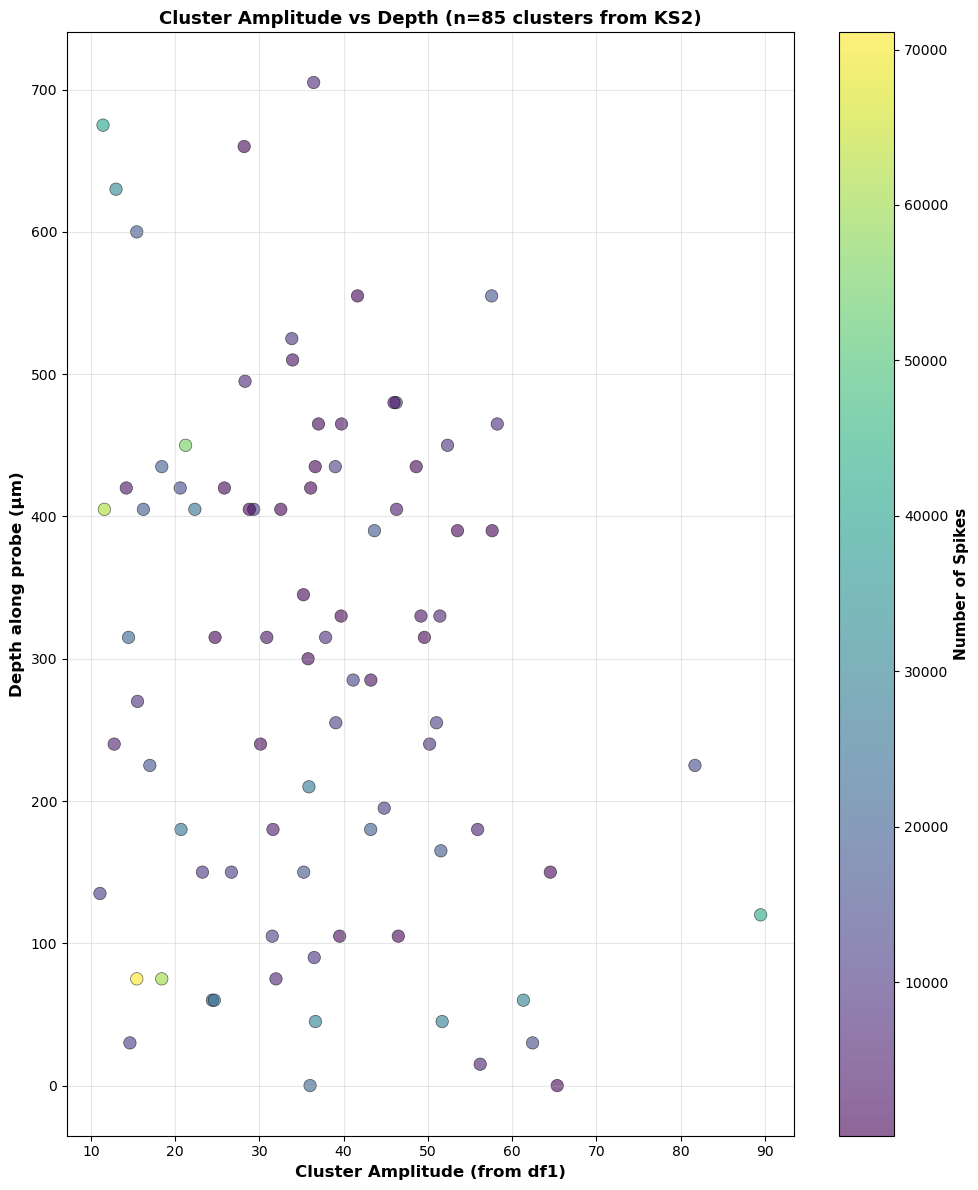


✓ Scatter plot created!


In [16]:
# Filter depths_df to only include clusters present in df1
#This is the results of the KS2 pipeline
clusters_in_df1= set(df1['cluster_id'].values)
depths_df1_filtered = depths_df1[depths_df1['cluster_id'].isin(clusters_in_df1)].copy()

# Merge with df1 to get the amplitude from df1
depths_df1_filtered = depths_df1_filtered.merge(df1[['cluster_id', 'amplitude']], on='cluster_id', how='left')

print(f"Total clusters with depth info: {len(depths_df1)}")
print(f"Clusters in df1: {len(df1)}")
print(f"Clusters in df1 with depth info: {len(depths_df1_filtered)}")
print(f"\nAmplitude statistics for df1 clusters:")
print(f"  Mean:   {depths_df1_filtered['amplitude'].mean():.4f}")
print(f"  Std:    {depths_df1_filtered['amplitude'].std():.4f}")
print(f"  Min:    {depths_df1_filtered['amplitude'].min():.4f}")
print(f"  Max:    {depths_df1_filtered['amplitude'].max():.4f}")

# Create scatter plot: amplitude vs depth (with depth inverted - 0 at top)
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(depths_df1_filtered['amplitude'], 
                     depths_df1_filtered['depth_um'],
                     s=80, alpha=0.6, c=depths_df1_filtered['n_spikes'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)

# Invert y-axis so 0 is at top and depth increases downwards (typical neural probe visualization)
#.invert_yaxis()

ax.set_xlabel('Cluster Amplitude (from df1)', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth along probe (µm)', fontsize=12, fontweight='bold')
ax.set_title(f'Cluster Amplitude vs Depth (n={len(depths_df1_filtered)} clusters from KS2)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar for spike count
cbar = plt.colorbar(scatter, ax=ax, label='Number of Spikes')
cbar.ax.set_ylabel('Number of Spikes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Scatter plot created!")

Metrics file loaded with 373 clusters

Metrics columns:
['Unnamed: 0', 'cluster_id', 'firing_rate', 'presence_ratio', 'isi_viol', 'num_viol', 'amplitude_cutoff', 'isolation_distance', 'contam_rate', 'l_ratio', 'd_prime', 'nn_hit_rate', 'nn_miss_rate', 'silhouette_score', 'max_drift', 'cumulative_drift', 'epoch_name_quality_metrics', 'epoch_name_waveform_metrics', 'peak_channel', 'snr', 'duration', 'halfwidth', 'PT_ratio', 'repolarization_slope', 'recovery_slope', 'amplitude', 'spread', 'velocity_above', 'velocity_below']

Metrics head:
   Unnamed: 0  cluster_id  firing_rate  presence_ratio  isi_viol  num_viol  \
0           0           0     5.027704            0.98  0.043049       8.0   
1           1           1     0.047231            0.31  0.000000       0.0   
2           2           3     0.001042            0.03  0.000000       0.0   
3           3           4     0.003473            0.09  0.000000       0.0   
4           4           5     0.445225            0.80  1.000000    

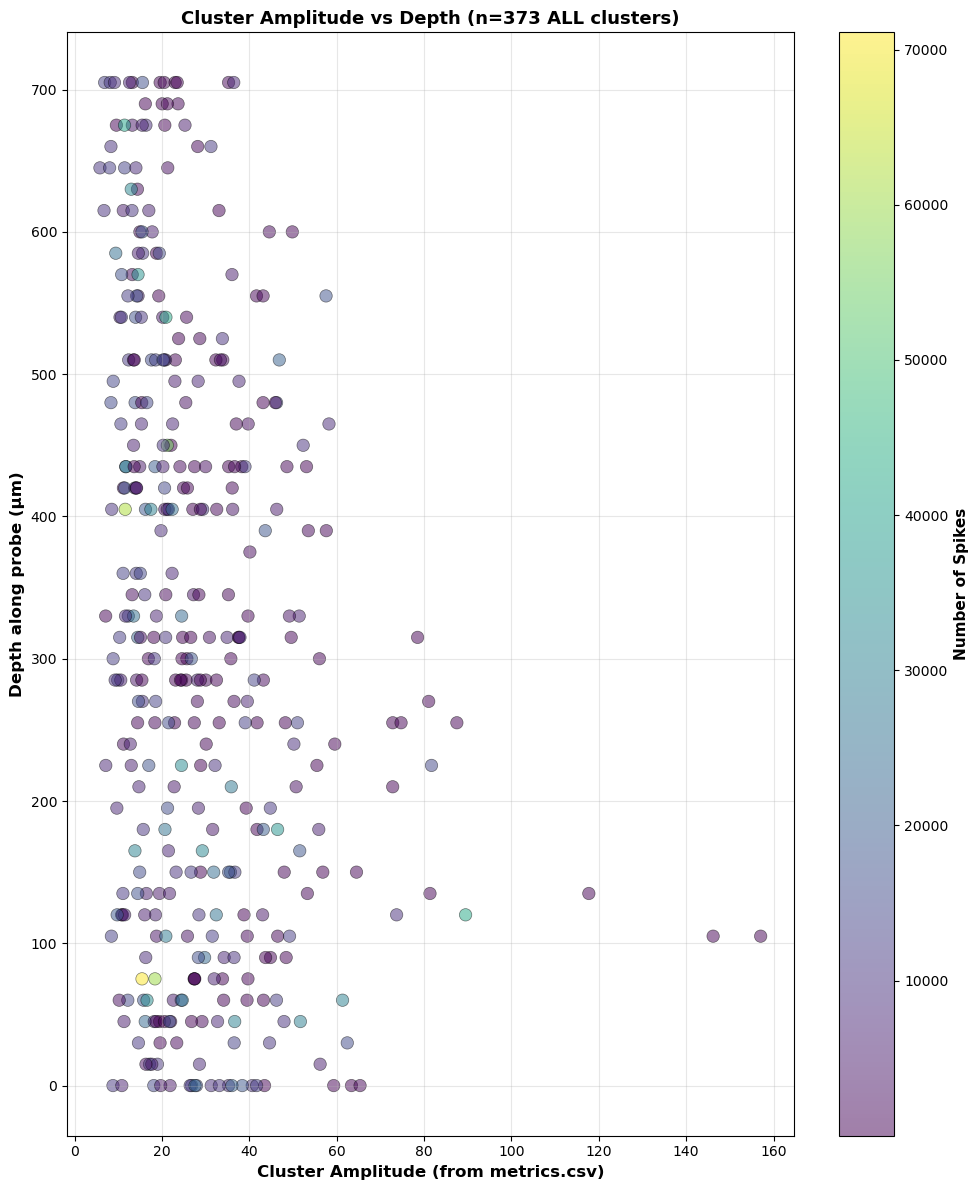


✓ Scatter plot created for all 373 clusters KS2!


In [17]:
# Load metrics.csv for all clusters
#This is the results of the \KS2 pipeline, all clusters this time 
#metrics_file = r'Z:\mvelez\mateoData_probe\CAA-1123475a\output\catgt_CAA-1123475a_rec1_g0\CAA-1123475a_rec1_g0_imec0\imec0_ks2\csv\metrics.csv'
metrics_file = r'/Volumes/margrie/mvelez/mateoData_probe/CAA-1123475a/output/catgt_CAA-1123475a_rec1_g0/CAA-1123475a_rec1_g0_imec0/imec0_ks2/csv/metrics.csv'

metrics_df = pd.read_csv(metrics_file)

print(f"Metrics file loaded with {len(metrics_df)} clusters")
print(f"\nMetrics columns:")
print(metrics_df.columns.tolist())
print(f"\nMetrics head:")
print(metrics_df.head())

# Merge depths_df with metrics_df
depths_df1_all = depths_df1.merge(metrics_df, left_on='cluster_id', right_on='cluster_id', how='left')

print(f"\n✓ Merged {len(depths_df1_all)} clusters with amplitude data from metrics.csv")
print(f"\nAmplitude statistics for ALL clusters:")
print(f"  Mean:   {depths_df1_all['amplitude'].mean():.4f}")
print(f"  Std:    {depths_df1_all['amplitude'].std():.4f}")
print(f"  Min:    {depths_df1_all['amplitude'].min():.4f}")
print(f"  Max:    {depths_df1_all['amplitude'].max():.4f}")
print(f"  Median: {depths_df1_all['amplitude'].median():.4f}")

# Create scatter plot for ALL clusters
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(depths_df1_all['amplitude'], 
                     depths_df1_all['depth_um'],
                     s=80, alpha=0.5, c=depths_df1_all['n_spikes'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)

# Invert y-axis so 0 is at top and depth increases downwards
#.invert_yaxis()

ax.set_xlabel('Cluster Amplitude (from metrics.csv)', fontsize=12, fontweight='bold')
ax.set_ylabel('Depth along probe (µm)', fontsize=12, fontweight='bold')
ax.set_title(f'Cluster Amplitude vs Depth (n={len(depths_df1_all)} ALL clusters)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar for spike count
cbar = plt.colorbar(scatter, ax=ax, label='Number of Spikes')
cbar.ax.set_ylabel('Number of Spikes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Scatter plot created for all {len(depths_df1_all)} clusters KS2!")

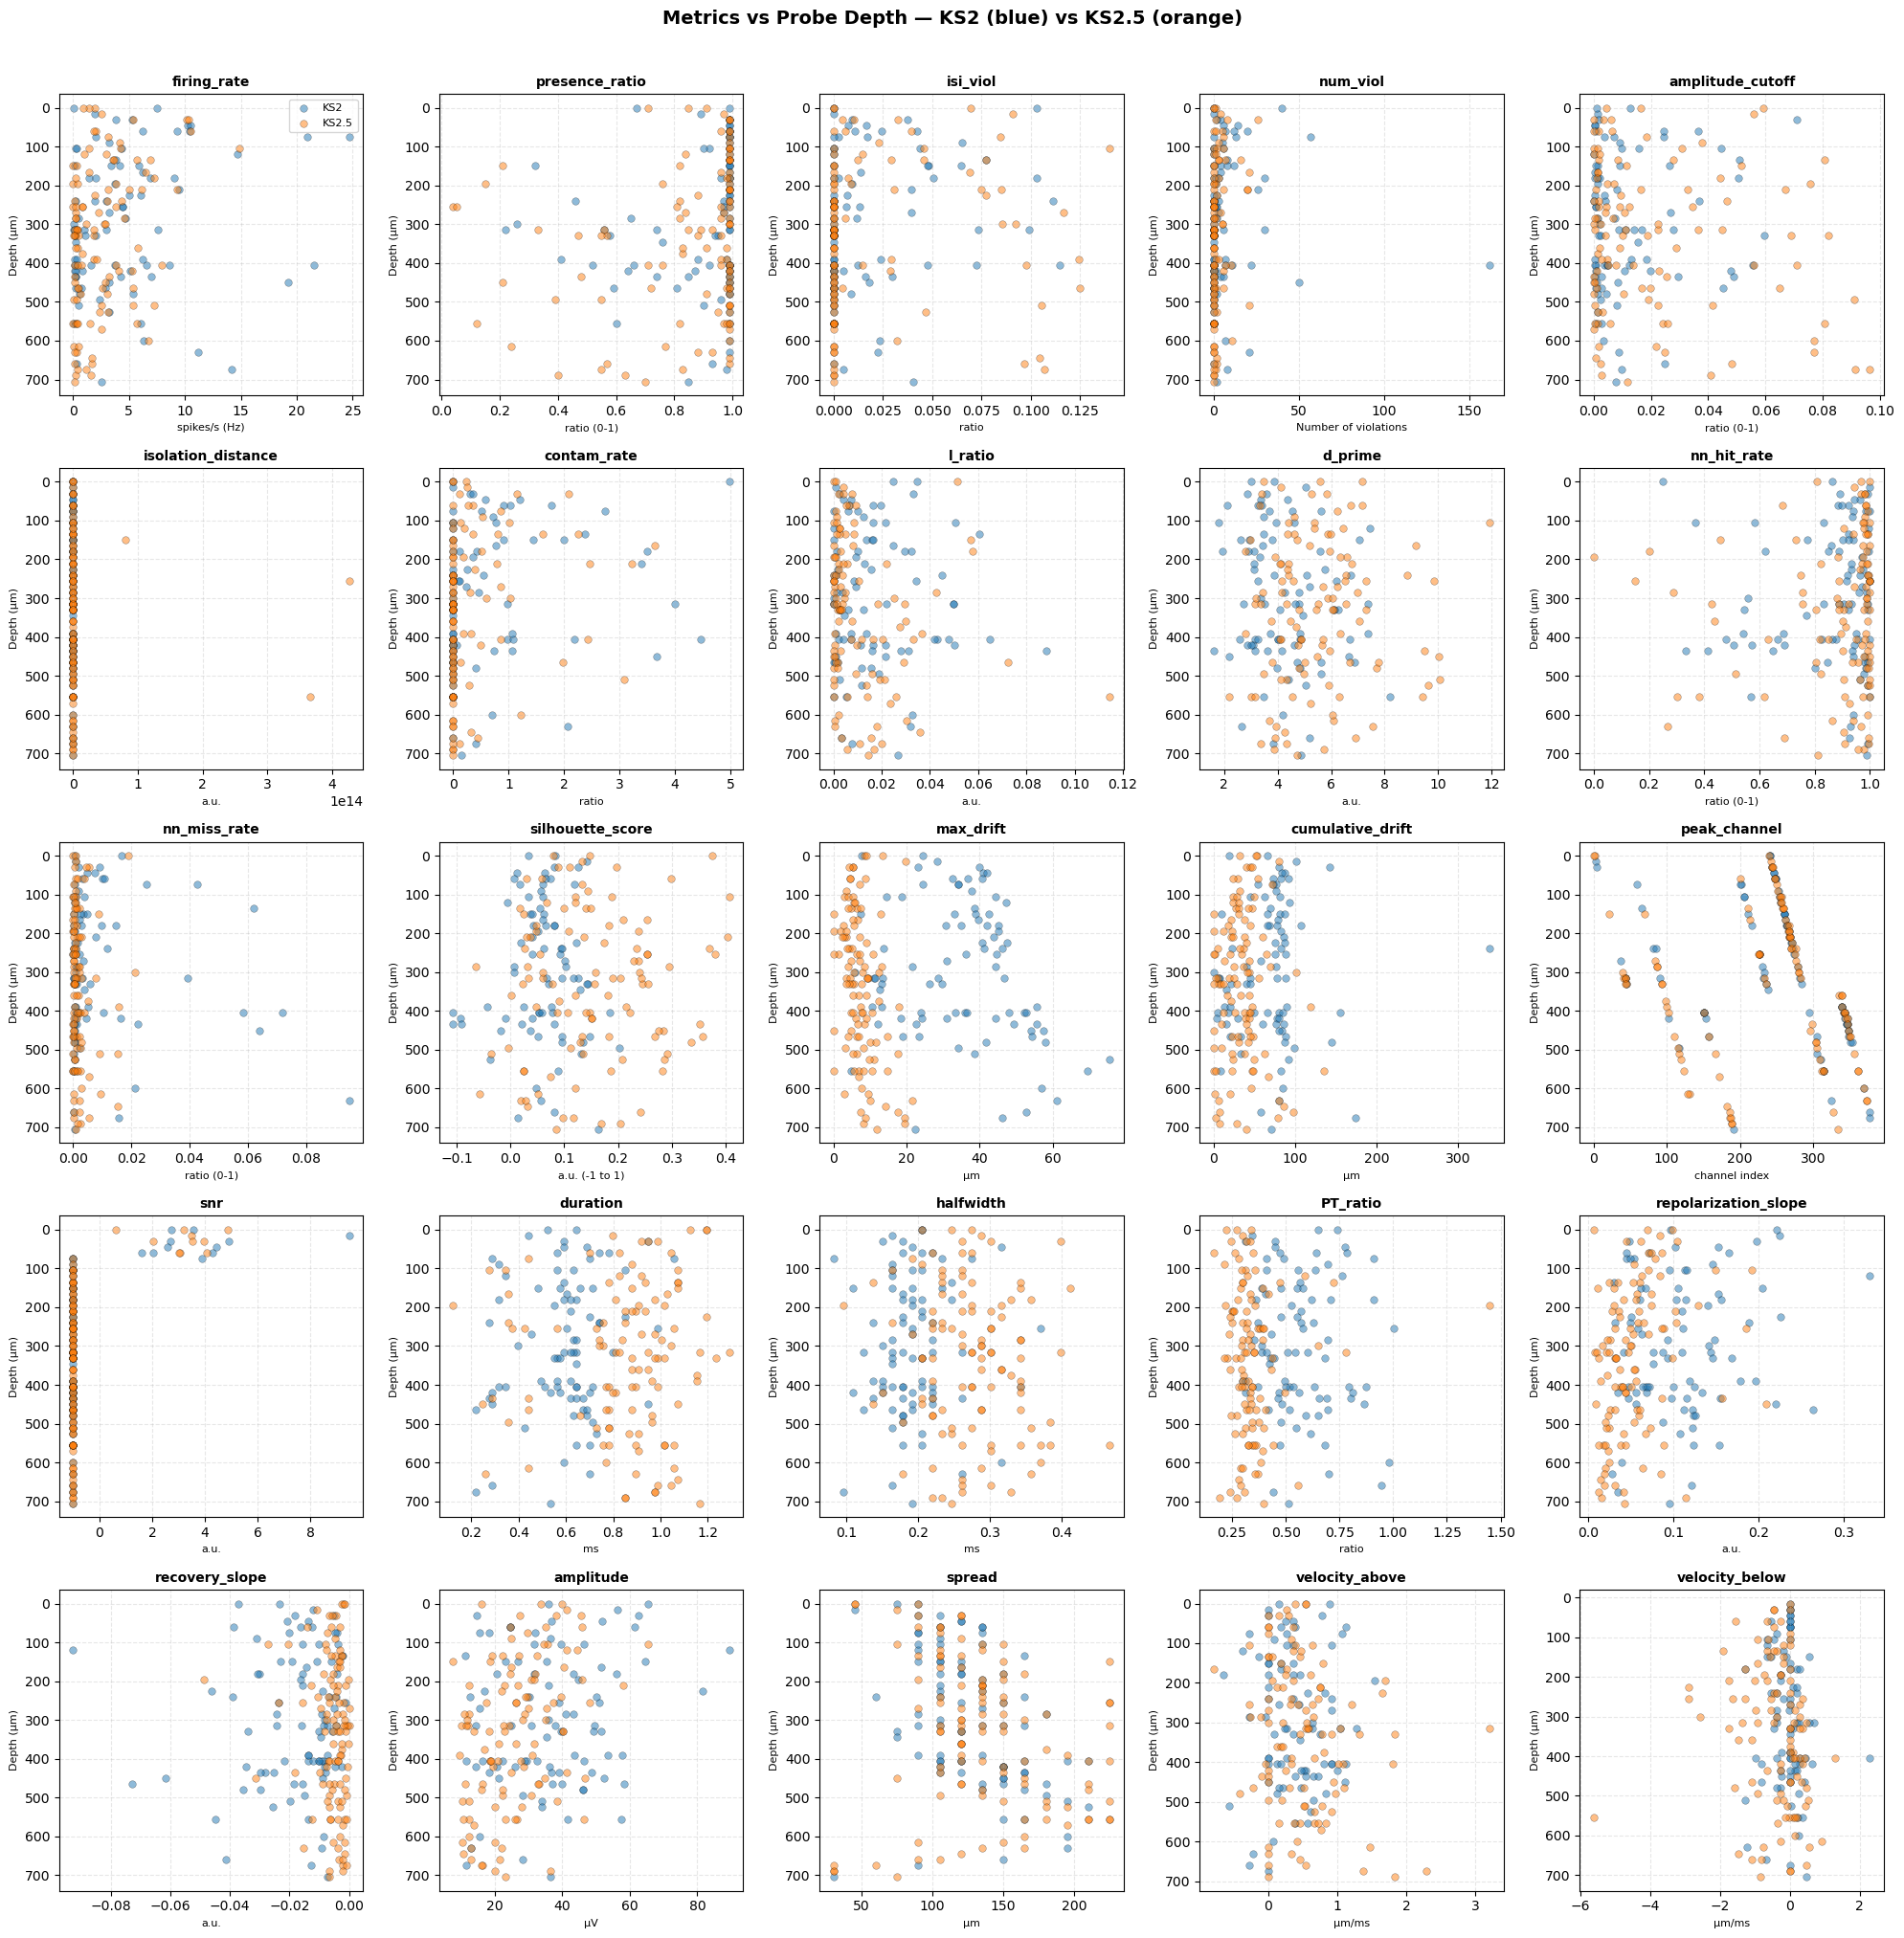

In [18]:
# ── SCATTER PLOTS: chaque métrique vs profondeur (KS2 vs KS2.5) ──────────────

# 1. Merger profondeur dans df1 et df2
df1_depth = df1.merge(depths_df1[['cluster_id', 'depth_um', 'n_spikes']], on='cluster_id', how='left')
df2_depth = df2.merge(depths_df[['cluster_id', 'depth_um', 'n_spikes']], on='cluster_id', how='left')

# 2. Colonnes à plotter
exclude_cols = {'Var1', 'cluster_id', 'depth_um', 'n_spikes',
                'epoch_name_quality_metrics', 'epoch_name_waveform_metrics'}
numeric_cols = [col for col in df1.columns
                if col not in exclude_cols and df1[col].dtype in ['float64', 'int64']]

# 3. Mise en page
n_cols = 5
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

colors = {'KS2': '#1f77b4', 'KS2.5': '#ff7f0e'}

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]

    for label, df_d, color in [('KS2', df1_depth, colors['KS2']),
                                ('KS2.5', df2_depth, colors['KS2.5'])]:
        valid = df_d[['depth_um', col]].dropna()
        ax.scatter(valid[col], valid['depth_um'],
                   alpha=0.5, s=30, label=label, color=color,
                   edgecolors='black', linewidth=0.3)

    ax.invert_yaxis()   # 0 µm en haut, profondeur croissante vers le bas
    ax.set_xlabel(units.get(col, 'a.u.'), fontsize=8)
    ax.set_ylabel('Depth (µm)', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    if idx == 0:
        ax.legend(fontsize=8)

# Supprimer les subplots vides
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Metrics vs Probe Depth — KS2 (blue) vs KS2.5 (orange)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()